## Importing the Data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
pd.set_option("display.max_columns", None)
folder = Path(r"C:\Users\Nonso_Fidelis\Desktop\Nonso Fidelis 2026\stocks-data-main\cache\nifty50_daily")

dfs = []

for file in folder.glob("*.csv"):
    df = pd.read_csv(file)
    df["Symbol"] = file.stem.replace("_daily", "")
    dfs.append(df)

nifty = pd.concat(dfs, ignore_index=True)

## Checking the shape of the data

In [5]:
nifty.shape

(312475, 22)

## Checking data description

In [6]:
nifty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312475 entries, 0 to 312474
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 312475 non-null  object 
 1   Open                 302019 non-null  float64
 2   High                 302019 non-null  float64
 3   Low                  302019 non-null  float64
 4   Close                302019 non-null  float64
 5   Volume               302019 non-null  float64
 6   Dividends            302019 non-null  float64
 7   Stock Splits         302019 non-null  float64
 8   ï»¿"Symbol"          10456 non-null   object 
 9   PrevClose            10456 non-null   object 
 10  OpenPrice            10456 non-null   object 
 11  HighPrice            10456 non-null   object 
 12  LowPrice             10456 non-null   object 
 13  LastPrice            10456 non-null   object 
 14  ClosePrice           10456 non-null   object 
 15  AveragePrice     

In [7]:
nifty.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,"ï»¿""Symbol""",PrevClose,OpenPrice,HighPrice,LowPrice,LastPrice,ClosePrice,AveragePrice,TotalTradedQuantity,TurnoverInRs,No.ofTrades,DeliverableQty,%DlyQttoTradedQty,Symbol
0,2002-07-01,-0.012187,-0.012522,-0.011920,-0.012173,1080397.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADANIENT
1,2002-07-02,-0.012385,-0.012426,-0.012118,-0.012269,1016147.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADANIENT
2,2002-07-03,-0.012255,-0.012392,-0.012194,-0.012269,980394.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADANIENT
3,2002-07-04,-0.012324,-0.012522,-0.012324,-0.012337,972747.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADANIENT
4,2002-07-05,-0.012406,-0.012406,-0.012262,-0.012310,974496.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADANIENT


### Apparently, after importing all 57 CSV files, i discovered that they were not all in the same format. There are two types of data inside the same folder

### The data contains Historical daily stock prices which contains OHLC (Open, High, Low, Close). The data also contains detailed NSE trading information contains market activity such as OpenPrice, ClosePrice, Number of Trades, Deliverable Quantity, Turnover, etc. 

# Separating OHLC data from NSE data

In [8]:
nifty = pd.concat(dfs, ignore_index=True)

# This is just to create a clean historical price dataset
ohlc = (nifty.loc[nifty["Open"].notna(),["Date", "Symbol", "Open", "High", "Low", "Close", "Volume"]].copy())

# This to create a separate NSE market activity dataset
nse = nifty.loc[nifty["OpenPrice"].notna()].copy()

# OHLC DATA ANALYSIS

In [9]:
ohlc.shape

(302019, 7)

In [10]:
ohlc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302019 entries, 0 to 312451
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Date    302019 non-null  object 
 1   Symbol  302019 non-null  object 
 2   Open    302019 non-null  float64
 3   High    302019 non-null  float64
 4   Low     302019 non-null  float64
 5   Close   302019 non-null  float64
 6   Volume  302019 non-null  float64
dtypes: float64(5), object(2)
memory usage: 18.4+ MB


In [11]:
ohlc["Date"] = pd.to_datetime(ohlc["Date"])
ohlc = ohlc.sort_values(["Symbol", "Date"]).reset_index(drop=True)

In [12]:
ohlc.isna().sum()

Date      0
Symbol    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

## NUmber of Stocks

In [13]:
print("Number of Stocks, ",ohlc["Symbol"].nunique())
print("")
print(ohlc["Symbol"].unique())

Number of Stocks,  49

['ADANIENT' 'ADANIPORTS' 'APOLLOHOSP' 'ASIANPAINT' 'AXISBANK' 'BAJAJ-AUTO'
 'BAJAJFINSV' 'BAJFINANCE' 'BHARTIARTL' 'BPCL' 'BRITANNIA' 'CIPLA'
 'COALINDIA' 'DIVISLAB' 'DRREDDY' 'EICHERMOT' 'GRASIM' 'HCLTECH'
 'HDFCBANK' 'HDFCLIFE' 'HEROMOTOCO' 'HINDALCO' 'HINDUNILVR' 'ICICIBANK'
 'INDUSINDBK' 'INFY' 'ITC' 'JSWSTEEL' 'KOTAKBANK' 'LT' 'LTIM' 'M&M'
 'MARUTI' 'NESTLEIND' 'NTPC' 'ONGC' 'POWERGRID' 'RELIANCE' 'SBILIFE'
 'SBIN' 'SUNPHARMA' 'TATACONSUM' 'TATASTEEL' 'TCS' 'TECHM' 'TITAN'
 'ULTRACEMCO' 'UPL' 'WIPRO']


## Observation period

In [14]:
print(ohlc["Date"].min())
print(ohlc["Date"].max())

1996-01-01 00:00:00
2026-02-02 00:00:00


## Number of records per stock - Just showing 10

In [15]:
ohlc["Symbol"].value_counts().sort_values(ascending=False).head(10)

Symbol
WIPRO         7555
HINDUNILVR    7555
TATASTEEL     7555
TITAN         7555
SUNPHARMA     7555
INFY          7555
HDFCBANK      7555
HINDALCO      7555
CIPLA         7554
BRITANNIA     7554
Name: count, dtype: int64

# Feature Engineering

In [16]:
import numpy as np
ohlc["PriceVariance"] = ohlc["High"] - ohlc["Low"]  # Daily Price Variance

ohlc["DailyReturn"] = (ohlc.groupby("Symbol")["Close"].pct_change()) #Dailt Return


ohlc["MA20"] = (ohlc.groupby("Symbol")["Close"].transform(lambda x: x.rolling(20).mean()))# Moving Averages

ohlc["MA50"] = (ohlc.groupby("Symbol")["Close"].transform(lambda x: x.rolling(50).mean()))


ohlc["Signal"] = np.select([ohlc["MA20"] > ohlc["MA50"],ohlc["MA20"] < ohlc["MA50"]],["BUY", "SELL"],default="")# This isthe Buy/Sell Signal

# Candlestick Type
ohlc["CandleType"] = np.select(
    [ohlc["Close"] > ohlc["Open"],
     ohlc["Close"] < ohlc["Open"]],
    ["Bullish", "Bearish"],
    default="Doji"
)

### How has stock price volatility changed over time

Measures how much stock prices fluctuate over time.

In [38]:
ohlc.groupby("Year")["PriceVariance"].mean()

Year
1996     0.298182
1997     0.374087
1998     0.453038
1999     0.954028
2000     1.494153
2001     0.984301
2002     1.177618
2003     2.193202
2004     3.599393
2005     3.738213
2006     7.163849
2007     8.511242
2008     8.492443
2009     6.943156
2010     6.944104
2011     7.831343
2012     7.868542
2013     9.754768
2014    12.064020
2015    15.849425
2016    15.901856
2017    16.635616
2018    23.426035
2019    23.447567
2020    32.462874
2021    37.714133
2022    40.220208
2023    34.581153
2024    53.136277
2025    49.681196
2026    59.345591
Name: PriceVariance, dtype: float64

<Axes: title={'center': 'Yearly Average Stock Volatility'}, xlabel='Year', ylabel='Average Price Variance'>

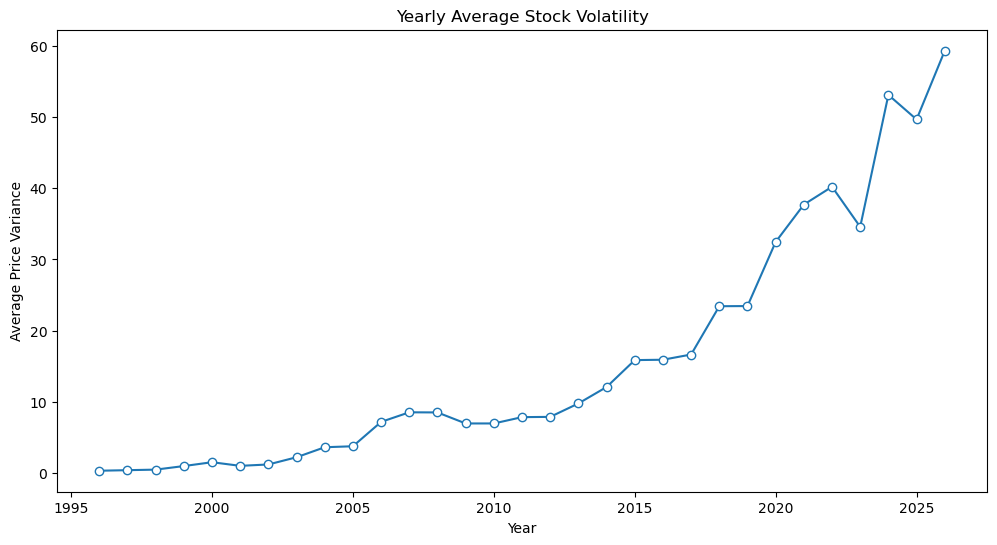

In [17]:
ohlc["Year"] = ohlc["Date"].dt.year
ohlc.groupby("Year")["PriceVariance"].mean().plot(figsize=(12, 6), marker="o", 
                                                  title="Yearly Average Stock Volatility", 
                                                  xlabel="Year", ylabel="Average Price Variance", markerfacecolor="white")


## How have trading volumes changed over time?

In [39]:
ohlc.groupby("Year")["Volume"].mean()

Year
1996    3.781317e+07
1997    4.465046e+07
1998    2.308432e+07
1999    1.663759e+07
2000    1.232709e+07
2001    1.123778e+07
2002    7.516553e+06
2003    1.038188e+07
2004    1.067298e+07
2005    7.720248e+06
2006    6.446124e+06
2007    5.827363e+06
2008    7.926773e+06
2009    1.058791e+07
2010    6.889944e+06
2011    6.135013e+06
2012    6.008371e+06
2013    6.394339e+06
2014    6.082995e+06
2015    5.575422e+06
2016    6.361003e+06
2017    6.060088e+06
2018    7.275334e+06
2019    8.706127e+06
2020    1.615711e+07
2021    1.171986e+07
2022    7.347425e+06
2023    6.384099e+06
2024    7.718493e+06
2025    5.304464e+06
2026    6.346483e+06
Name: Volume, dtype: float64

<Axes: title={'center': 'Yearly Average Trading Volume'}, xlabel='Year', ylabel='Average Trading Volume'>

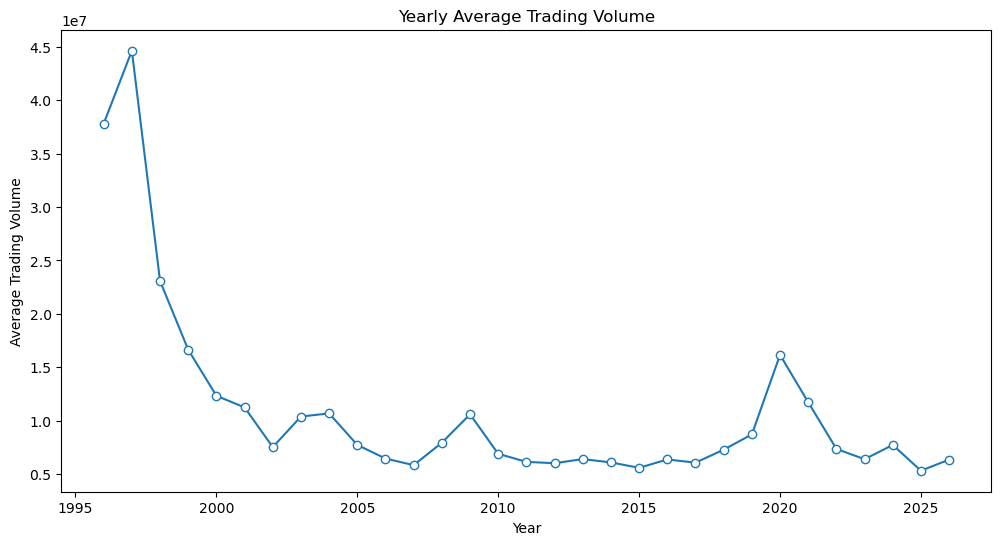

In [18]:
ohlc.groupby("Year")["Volume"].mean().plot(figsize=(12, 6), marker="o", 
                                           title="Yearly Average Trading Volume", 
                                           xlabel="Year", ylabel="Average Trading Volume", markerfacecolor="white")


## Has market sentiment become more bullish or bearish?

In [41]:
(ohlc["CandleType"] == "Bullish").groupby(ohlc["Year"]).mean()

Year
1996    0.462219
1997    0.446864
1998    0.444823
1999    0.413602
2000    0.422308
2001    0.435620
2002    0.423366
2003    0.426237
2004    0.422758
2005    0.435565
2006    0.432696
2007    0.442118
2008    0.433424
2009    0.470782
2010    0.457750
2011    0.465712
2012    0.498580
2013    0.477735
2014    0.485923
2015    0.454312
2016    0.462016
2017    0.458461
2018    0.465323
2019    0.460066
2020    0.458005
2021    0.451613
2022    0.483130
2023    0.465306
2024    0.457110
2025    0.484387
2026    0.453618
Name: CandleType, dtype: float64

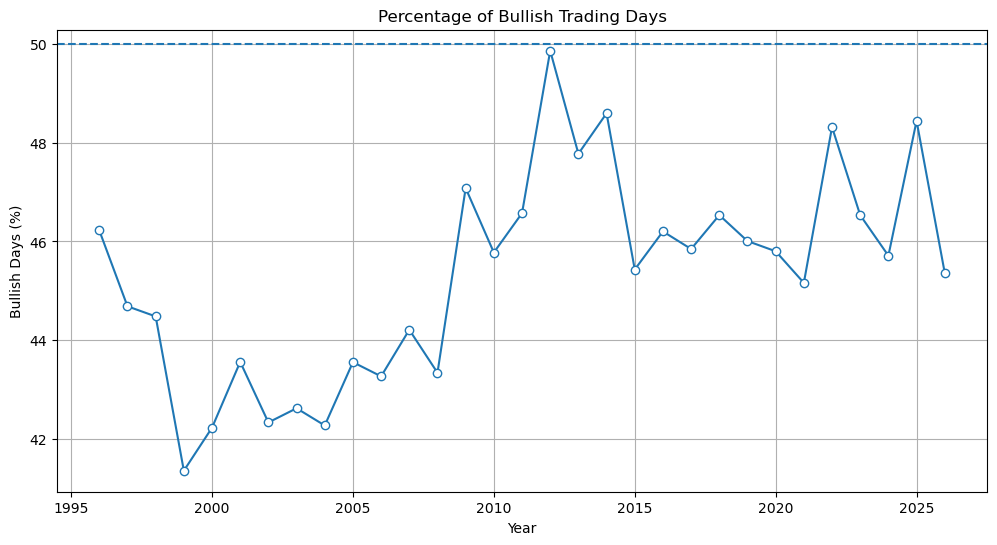

In [19]:
((ohlc["CandleType"] == "Bullish").groupby(ohlc["Year"]).mean().mul(100)).plot(figsize=(12, 6), 
                                                                               marker="o", 
                                                                               title="Percentage of Bullish Trading Days", 
                                                                               xlabel="Year", ylabel="Bullish Days (%)", 
                                                                               markerfacecolor="white")

plt.axhline(50, linestyle="--")
plt.grid(True)

## Which stocks are the most volatile?

In [42]:
volatility.head(20)

Symbol
BAJFINANCE    1.418032
TATASTEEL     0.390398
CIPLA         0.277963
ADANIENT      0.127816
EICHERMOT     0.108386
KOTAKBANK     0.089032
GRASIM        0.075054
BPCL          0.063633
WIPRO         0.059583
DRREDDY       0.053314
M&M           0.051090
RELIANCE      0.046994
TCS           0.035546
ONGC          0.032768
INDUSINDBK    0.028978
JSWSTEEL      0.028945
UPL           0.027966
TITAN         0.027938
BAJAJFINSV    0.027282
AXISBANK      0.027038
Name: DailyReturn, dtype: float64

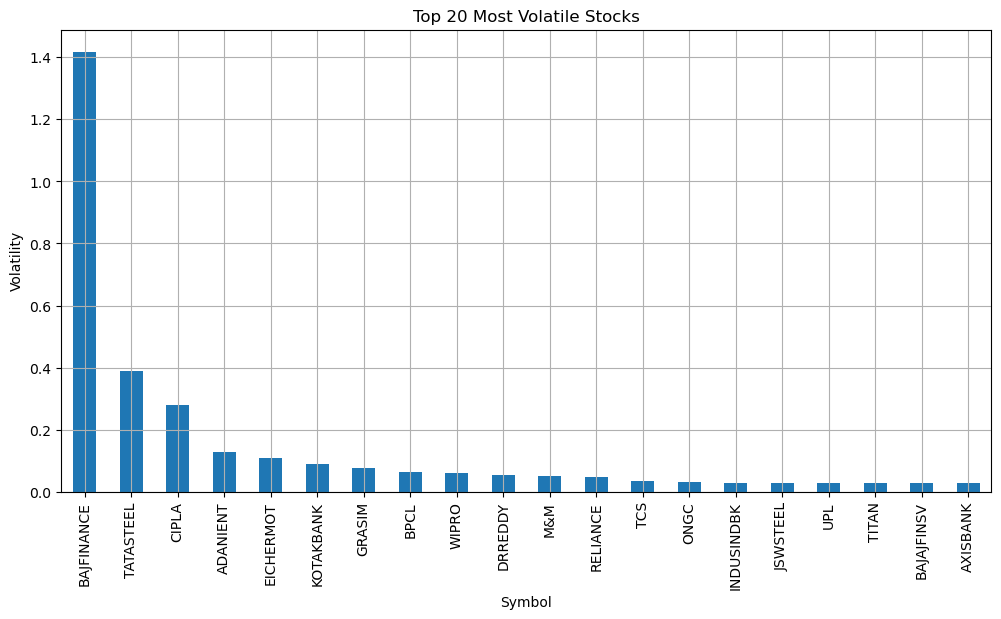

In [20]:
volatility = ohlc.groupby("Symbol")["DailyReturn"].std().sort_values(ascending=False)

volatility.head(20).plot(kind="bar", figsize=(12, 6), title="Top 20 Most Volatile Stocks", ylabel="Volatility")

plt.grid(True)
plt.show()

## Which stocks have the highest average trading volume?

In [43]:
ohlc.groupby("Symbol")["Volume"].mean().sort_values(ascending=False).head(20)

Symbol
TATASTEEL     6.674951e+07
RELIANCE      5.793796e+07
ITC           4.301913e+07
SBIN          3.014632e+07
ICICIBANK     1.857869e+07
INFY          1.410216e+07
KOTAKBANK     1.362280e+07
WIPRO         1.335615e+07
HDFCBANK      1.223562e+07
POWERGRID     1.193603e+07
BAJFINANCE    9.563388e+06
NTPC          9.553258e+06
ONGC          8.789527e+06
BPCL          8.524209e+06
JSWSTEEL      7.674254e+06
AXISBANK      7.611545e+06
COALINDIA     7.217284e+06
BHARTIARTL    6.914195e+06
ADANIENT      6.446627e+06
HINDALCO      5.981239e+06
Name: Volume, dtype: float64

<Axes: title={'center': 'Top 20 Stocks by Average Trading Volume'}, xlabel='Symbol', ylabel='Average Volume'>

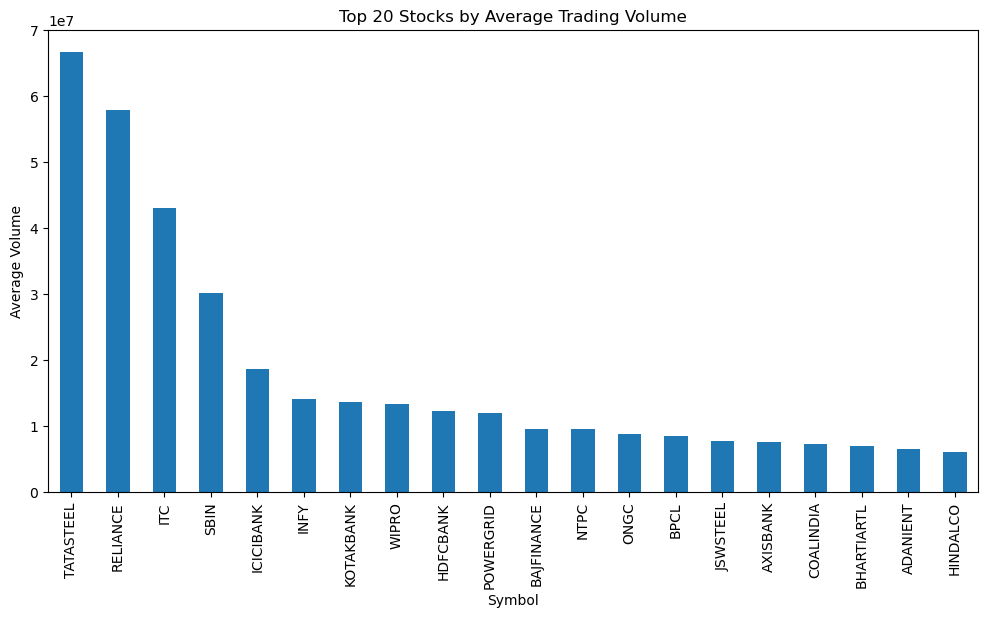

In [21]:
ohlc.groupby("Symbol")["Volume"].mean().sort_values(ascending=False).head(20).plot(kind="bar", 
                                                                                   figsize=(12, 6), 
                                                                                   title="Top 20 Stocks by Average Trading Volume", ylabel="Average Volume")

## Which stocks generate the most BUY and SELL signals?

<Axes: title={'center': 'Stocks with the Most Trading Signals'}, xlabel='Symbol', ylabel='Signal Count'>

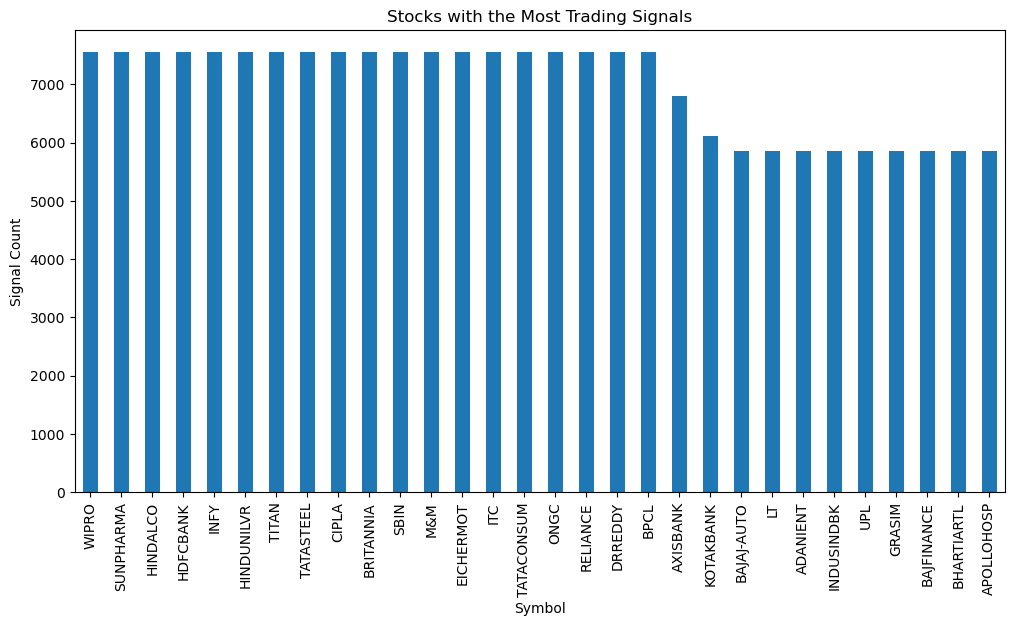

In [22]:
signal_summary = ohlc.groupby(["Symbol", "Signal"]).size().unstack(fill_value=0)

signal_summary.sum(axis=1).sort_values(ascending=False).head(30).plot(kind="bar", 
                                                                      figsize=(12, 6), 
                                                                      title="Stocks with the Most Trading Signals", 
                                                                      ylabel="Signal Count")

## Which stocks are both highly traded and highly volatile?

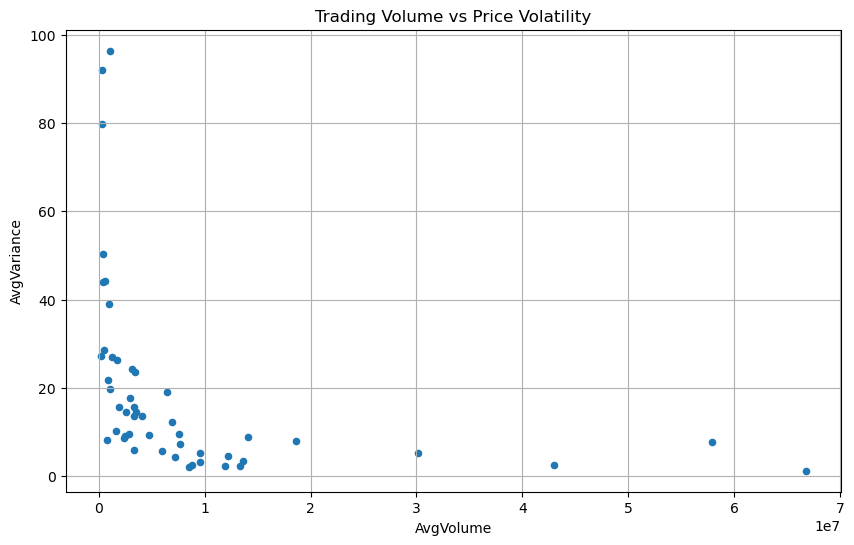

In [23]:
summary = ohlc.groupby("Symbol").agg(AvgVolume=("Volume", "mean"), AvgVariance=("PriceVariance", "mean"))

summary.plot.scatter(x="AvgVolume", y="AvgVariance", figsize=(10, 6), title="Trading Volume vs Price Volatility")

plt.grid(True)
plt.show()

## Is trading volume related to price volatility?

In [45]:
ohlc[["Volume","PriceVariance"]].corr()

,Volume,PriceVariance
Volume,1.000000,-0.094407
PriceVariance,-0.094407,1.000000


<Axes: >

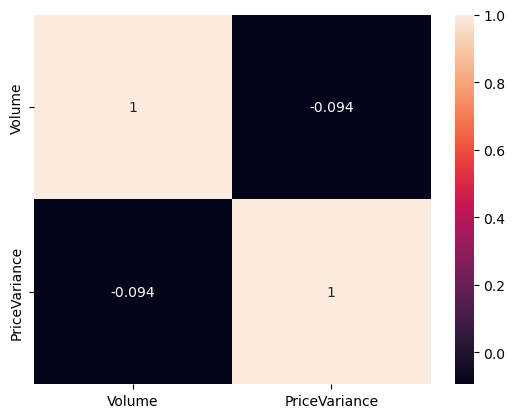

In [24]:
sns.heatmap(ohlc[["Volume","PriceVariance"]].corr(),annot=True)

## What proportion of trading days are Bullish, Bearish, and Doji?

In [47]:
ohlc["CandleType"].value_counts()

CandleType
Bearish    157510
Bullish    137738
Doji         6771
Name: count, dtype: int64

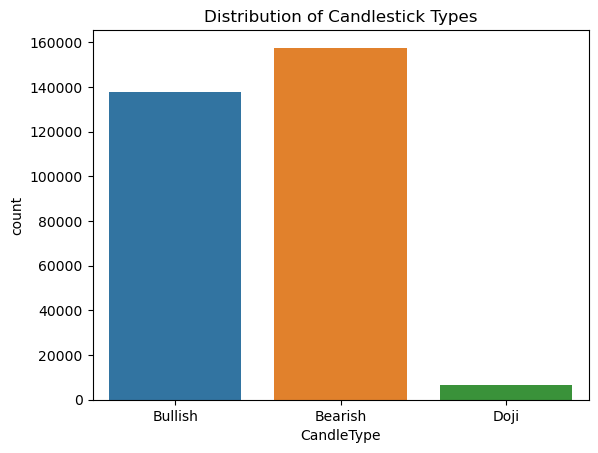

In [25]:
sns.countplot(data=ohlc,x="CandleType")

plt.title("Distribution of Candlestick Types")
plt.show()

## Which month of the year has the highest average return?

In [48]:
ohlc.groupby("Month")["DailyReturn"].mean()

Month
April        0.004342
August       0.001028
December     0.002705
February     0.000290
January      0.000084
July         0.006673
June         0.001069
March        0.001646
May          0.001386
November     0.003679
October      0.000681
September    0.001294
Name: DailyReturn, dtype: float64

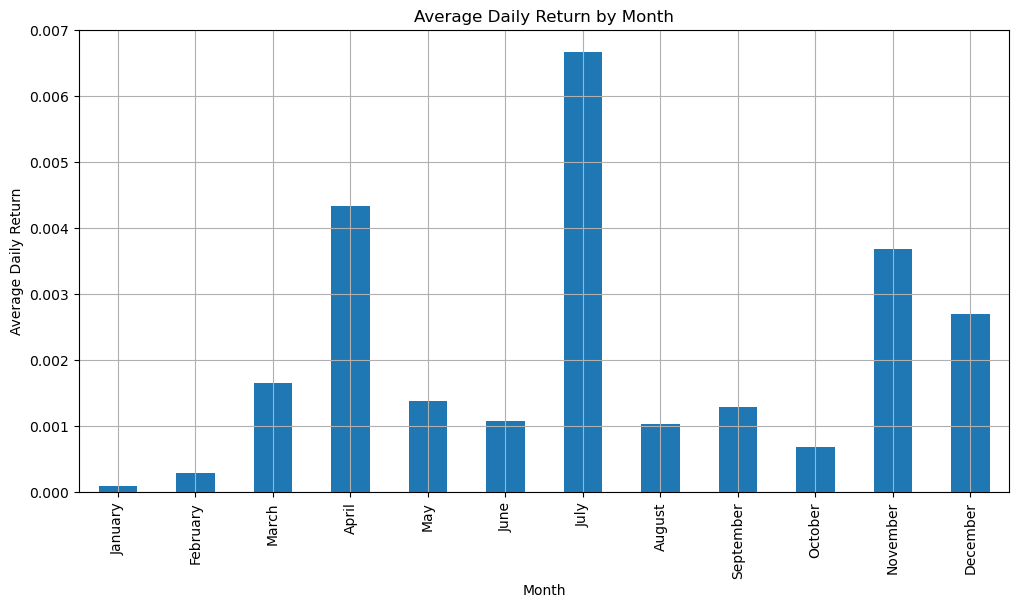

In [26]:
ohlc["Month"] = ohlc["Date"].dt.month_name()

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

ohlc.groupby("Month")["DailyReturn"].mean().reindex(month_order).plot(kind="bar", figsize=(12, 6), title="Average Daily Return by Month", ylabel="Average Daily Return")

plt.grid(True)
plt.show()

## Which month has the highest trading volume?

In [49]:
ohlc.groupby("Month")["Volume"].mean()

Month
April        9.485145e+06
August       8.921725e+06
December     8.280941e+06
February     9.903125e+06
January      9.480111e+06
July         9.743346e+06
June         9.896180e+06
March        1.001321e+07
May          9.993017e+06
November     9.140023e+06
October      9.536118e+06
September    9.149273e+06
Name: Volume, dtype: float64

<Axes: title={'center': 'Average Trading Volume by Month'}, xlabel='Month', ylabel='Average Trading Volume'>

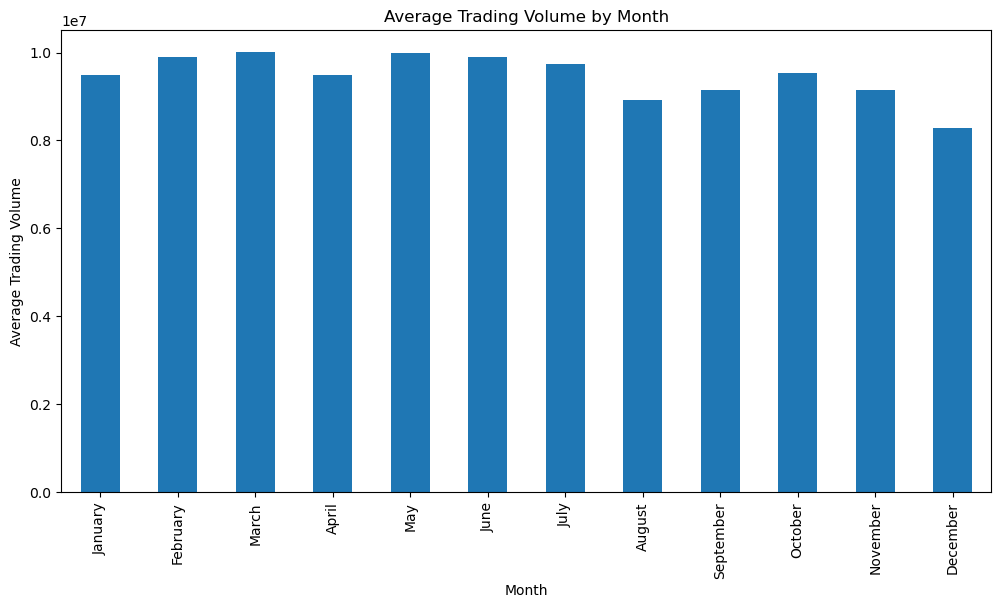

In [27]:
ohlc.groupby("Month")["Volume"].mean().reindex(month_order).plot(kind="bar", figsize=(12, 6), title="Average Trading Volume by Month", ylabel="Average Trading Volume")

# NSE DATA Activity Analysis

### Which stocks have the highest trading turnover?

Trading Turnover measures the total monetary value of shares traded, helping identify the stocks that attract the highest capital investment and contribute most to overall market liquidity.

In [50]:
nse.groupby("Symbol")["TurnoverInRs"].mean().sort_values(ascending=False).head(20)

Symbol
HDFCBANK      2.721536e+10
INFY          2.296314e+10
ICICIBANK     2.004364e+10
SBIN          1.979837e+10
RELIANCE      1.853618e+10
BHARTIARTL    1.645581e+10
TCS           1.306922e+10
LT            1.105965e+10
TMPV          9.674552e+09
ETERNAL       8.876603e+09
M&M           8.555040e+09
BAJFINANCE    8.181071e+09
AXISBANK      7.826519e+09
TATASTEEL     7.060255e+09
ITC           6.635512e+09
KOTAKBANK     6.541566e+09
ONGC          6.369717e+09
JIOFIN        6.318952e+09
HINDALCO      5.808453e+09
HCLTECH       5.530609e+09
Name: TurnoverInRs, dtype: float64

<Axes: title={'center': 'Top 20 Stocks by Average Trading Turnover'}, xlabel='Symbol', ylabel='Average Turnover (₹)'>

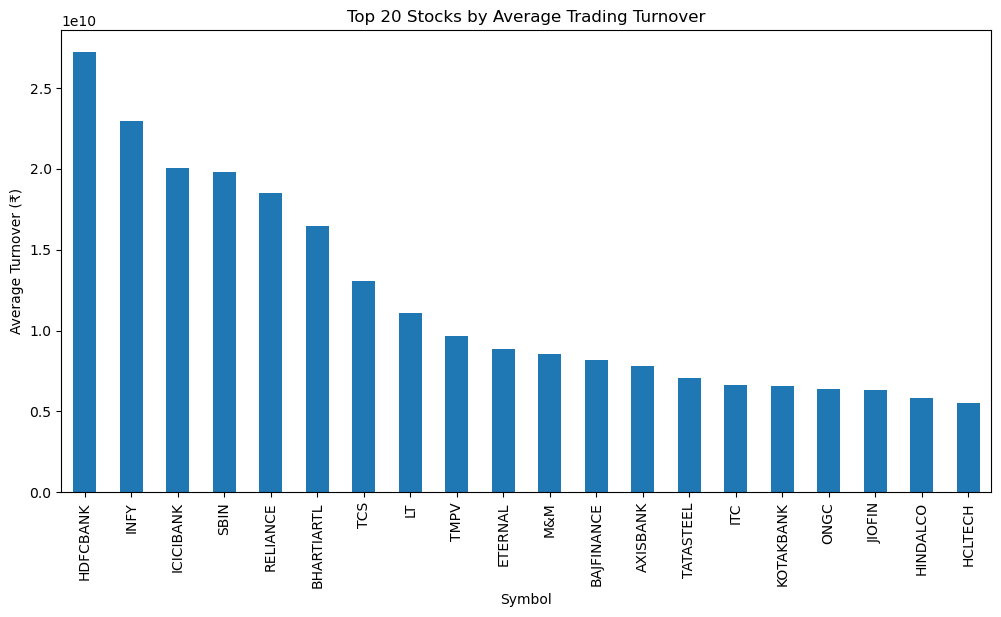

In [28]:
nse.groupby("Symbol")["TurnoverInRs"].mean().sort_values(ascending=False).head(20).plot(kind="bar", figsize=(12, 6), title="Top 20 Stocks by Average Trading Turnover", ylabel="Average Turnover (₹)")

## Which stocks have the highest number of trades?

indicates how frequently a stock is bought and sold, making it useful for identifying the most actively traded securities in the market.

In [51]:
nse.groupby("Symbol")["No.ofTrades"].mean().sort_values(ascending=False).head(20)

Symbol
HDFCBANK      367227.043478
INFY          349231.434783
SBIN          278448.608696
TMPV          241206.706677
ICICIBANK     237801.652174
TCS           235535.434783
TATASTEEL     230079.434783
RELIANCE      229100.304348
ONGC          217772.260870
BHARTIARTL    211246.739130
ETERNAL       209050.369338
ITC           192599.869565
NTPC          179762.173913
WIPRO         169239.086957
JIOFIN        165141.616114
LT            157892.043478
POWERGRID     149410.000000
HINDALCO      147961.304348
BAJFINANCE    147025.608696
AXISBANK      145846.173913
Name: No.ofTrades, dtype: float64

<Axes: title={'center': 'Top 20 Stocks by Average Number of Trades'}, xlabel='Symbol', ylabel='Average Number of Trades'>

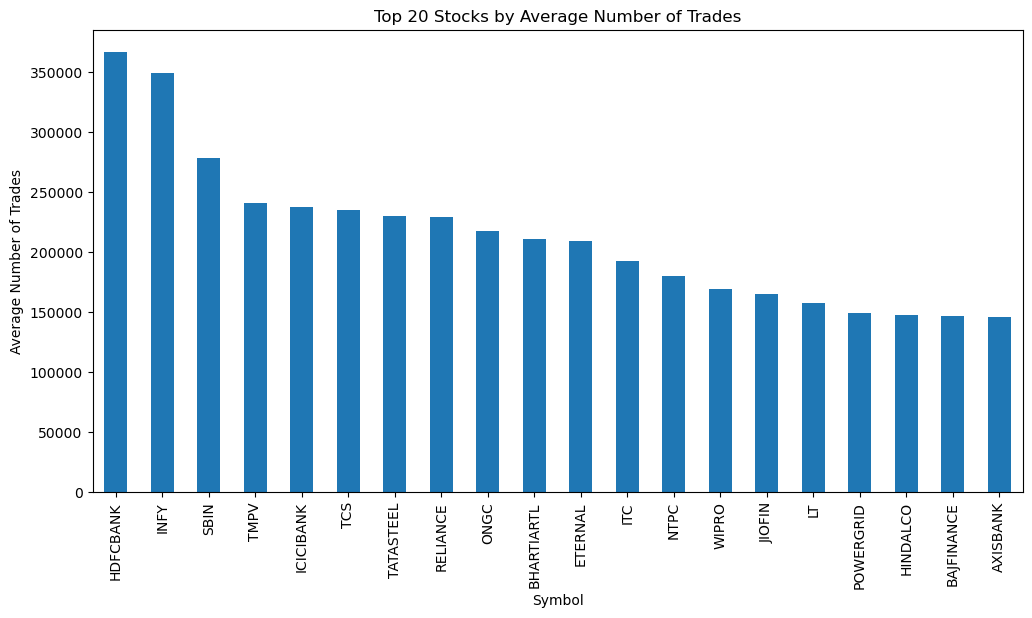

In [29]:
nse.groupby("Symbol")["No.ofTrades"].mean().sort_values(ascending=False).head(20).plot(kind="bar", figsize=(12, 6), title="Top 20 Stocks by Average Number of Trades", ylabel="Average Number of Trades")


## Which stocks have the highest traded quantity?

Delivery Percentage measures the proportion of traded shares held for delivery rather than intraday trading, making it useful for assessing long-term investor interest.

In [52]:
nse.groupby("Symbol")["TotalTradedQuantity"].mean().sort_values(ascending=False).head(20)

Symbol
ETERNAL       6.073466e+07
TATASTEEL     3.445649e+07
HDFCBANK      2.980873e+07
ONGC          2.316850e+07
JIOFIN        2.181635e+07
ITC           2.074959e+07
TMPV          1.908474e+07
WIPRO         1.784363e+07
BEL           1.779574e+07
POWERGRID     1.720466e+07
SBIN          1.689835e+07
INFY          1.662073e+07
KOTAKBANK     1.561180e+07
ICICIBANK     1.442577e+07
RELIANCE      1.314353e+07
NTPC          1.113341e+07
COALINDIA     8.914618e+06
BHARTIARTL    8.412926e+06
BAJFINANCE    8.265692e+06
BPCL          7.229573e+06
Name: TotalTradedQuantity, dtype: float64

<Axes: title={'center': 'Top 20 Stocks by Average Traded Quantity'}, xlabel='Symbol', ylabel='Average Quantity'>

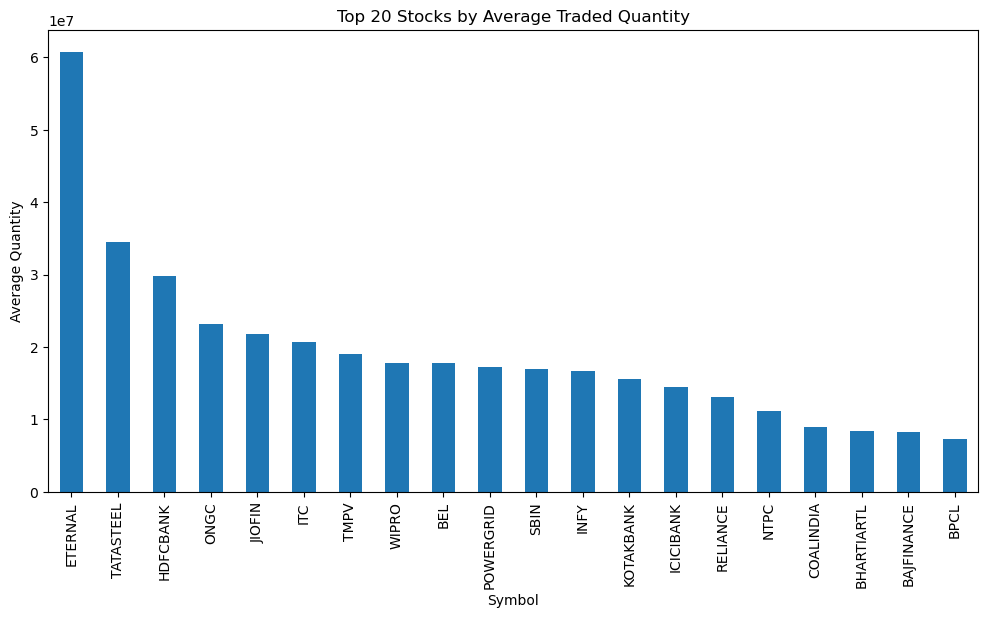

In [30]:
nse.groupby("Symbol")["TotalTradedQuantity"].mean().sort_values(ascending=False).head(20).plot(kind="bar", figsize=(12, 6), title="Top 20 Stocks by Average Traded Quantity", ylabel="Average Quantity")

# Is trading quantity related to turnover?

### evaluates whether larger trading quantities correspond to higher trading values, providing insight into market liquidity.

Text(0.5, 1.0, 'Trading Quantity vs Turnover')

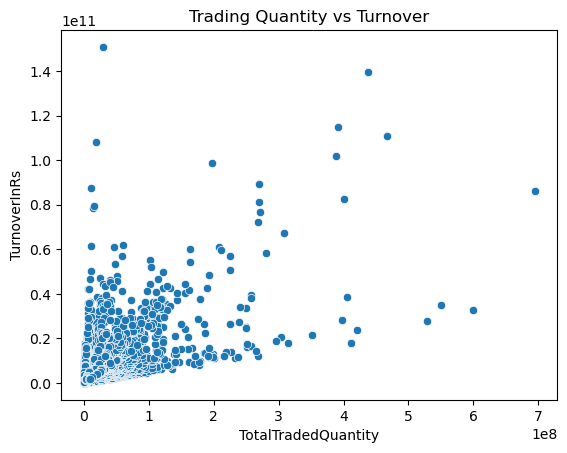

In [31]:
sns.scatterplot(
    data=nse,
    x="TotalTradedQuantity",
    y="TurnoverInRs"
)

plt.title("Trading Quantity vs Turnover")

# How has market turnover changed over time?

In [54]:
(
nse.groupby("Year")["TurnoverInRs"]
    .mean()
)

Year
2021    3.683393e+09
2022    2.579761e+09
2023    2.909635e+09
2024    6.874857e+09
2025    6.706509e+09
2026    6.235697e+09
Name: TurnoverInRs, dtype: float64

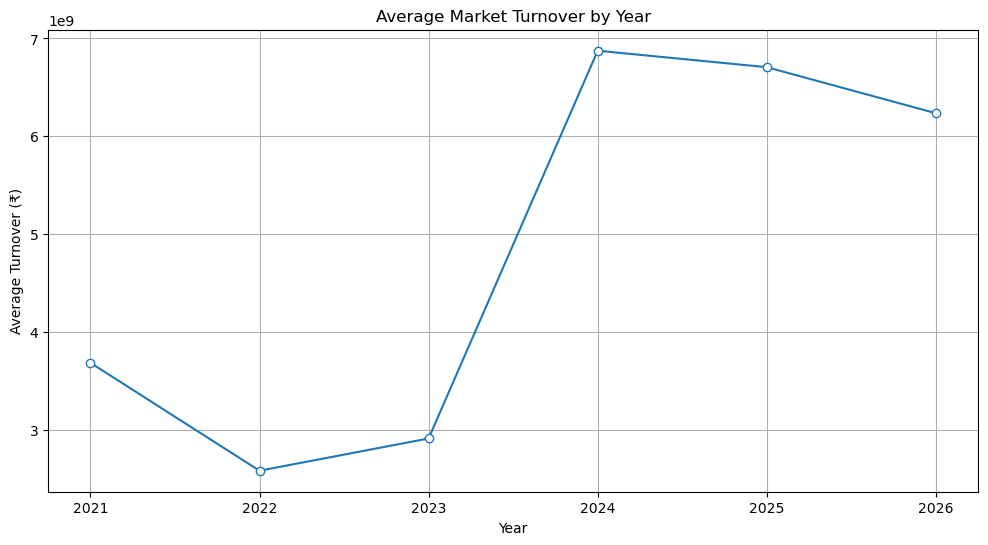

In [32]:
nse["Date"] = pd.to_datetime(nse["Date"])
nse["Year"] = nse["Date"].dt.year

(
nse.groupby("Year")["TurnoverInRs"]
    .mean()
).plot(
    figsize=(12,6),
    marker="o",
    title="Average Market Turnover by Year",
    ylabel="Average Turnover (₹)",
    markerfacecolor="white"
)

plt.grid(True)
plt.show()

## How has the number of trades changed over time?

In [53]:
(
    nse.groupby("Year")["No.ofTrades"]
    .mean()
)

Year
2021     90931.720946
2022     74809.402074
2023     81815.149558
2024    164651.339357
2025    142368.639056
2026    121801.775387
Name: No.ofTrades, dtype: float64

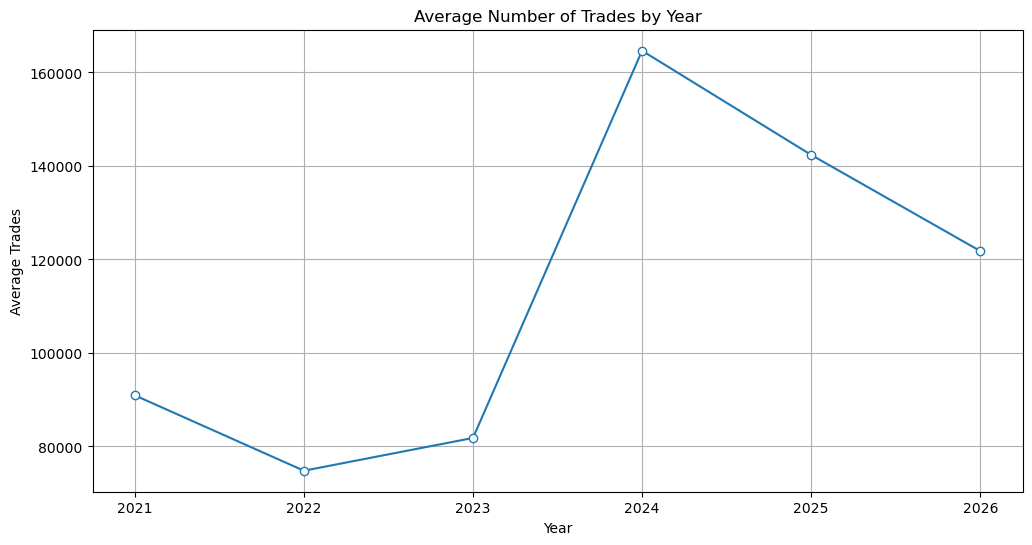

In [33]:
(
    nse.groupby("Year")["No.ofTrades"]
    .mean()
).plot(
    figsize=(12,6),
    marker="o",
    title="Average Number of Trades by Year",
    ylabel="Average Trades",
    markerfacecolor="white"
)

plt.grid(True)
plt.show()

## Which months have the highest trading activity?

In [55]:
(
    nse.groupby("Month")["TurnoverInRs"]
    .mean()
    .reindex(month_order)
)

Month
January      4.619526e+09
February     5.491031e+09
March        5.488409e+09
April        4.329870e+09
May          5.195728e+09
June         4.772306e+09
July         4.509033e+09
August       5.498997e+09
September    4.885860e+09
October      4.589426e+09
November     4.402729e+09
December     4.264807e+09
Name: TurnoverInRs, dtype: float64

<Axes: title={'center': 'Average Monthly Trading Turnover'}, xlabel='Month', ylabel='Average Turnover (₹)'>

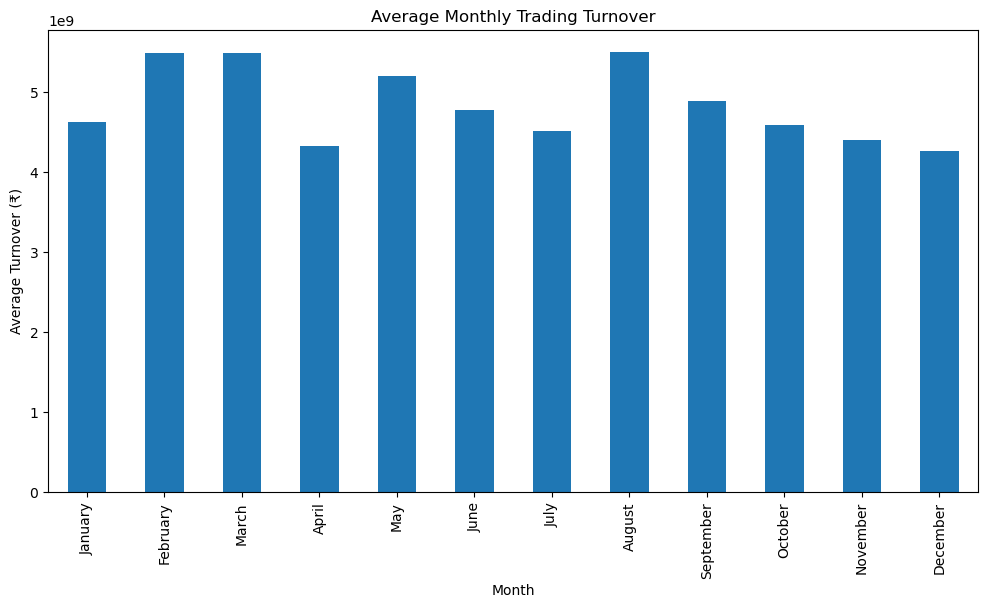

In [34]:
nse["Month"] = nse["Date"].dt.month_name()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

(
    nse.groupby("Month")["TurnoverInRs"]
    .mean()
    .reindex(month_order)
).plot(
    kind="bar",
    figsize=(12,6),
    title="Average Monthly Trading Turnover",
    ylabel="Average Turnover (₹)"
)

# Which stocks dominate market turnover?

In [56]:
nse.groupby("Symbol")["TurnoverInRs"].sum().sort_values(ascending=False).head(10)

Symbol
TMPV          1.217059e+13
ETERNAL       1.019034e+13
BEL           5.499516e+12
INDIGO        4.518999e+12
JIOFIN        3.999896e+12
TRENT         3.624811e+12
SHRIRAMFIN    2.242053e+12
MAXHEALTH     2.083064e+12
HDFCBANK      6.259532e+11
INFY          5.281521e+11
Name: TurnoverInRs, dtype: float64

Text(0.5, 1.0, 'Top 10 Stocks by Total Market Turnover')

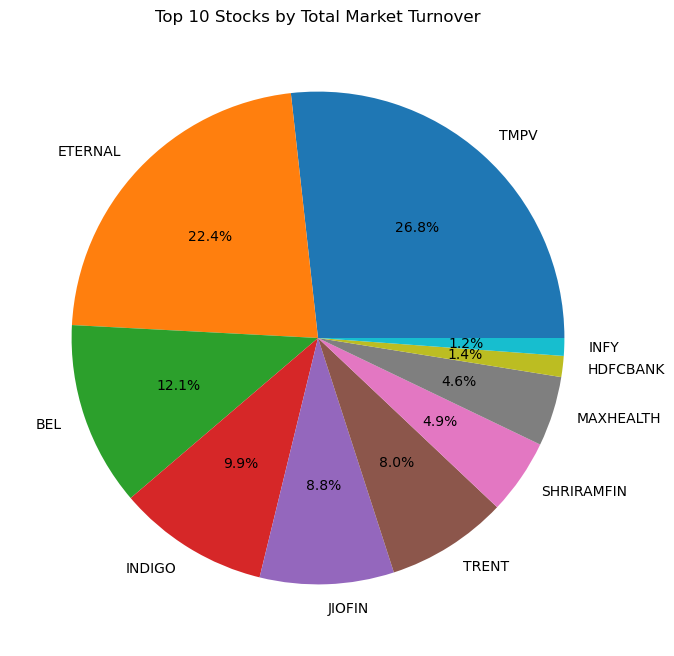

In [35]:
nse.groupby("Symbol")["TurnoverInRs"].sum().sort_values(ascending=False).head(10).plot(kind="pie", figsize=(8, 8), autopct="%1.1f%%")

plt.ylabel("")
plt.title("Top 10 Stocks by Total Market Turnover")

## Which stocks consistently attract the highest delivery volume?

#### his analysis identifies stocks that consistently experience the highest delivery volumes, indicating sustained investor ownership.

In [57]:
nse.groupby("Symbol")["DeliverableQty"].sum().sort_values(ascending=False).head(20)

Symbol
ETERNAL       2.876091e+10
BEL           1.020803e+10
TMPV          7.125146e+09
JIOFIN        6.139268e+09
MAXHEALTH     1.987411e+09
SHRIRAMFIN    1.185445e+09
INDIGO        6.212905e+08
TRENT         4.732619e+08
HDFCBANK      4.247409e+08
TATASTEEL     3.166688e+08
ITC           2.643812e+08
ONGC          2.557106e+08
POWERGRID     2.554056e+08
KOTAKBANK     2.440246e+08
SBIN          2.351152e+08
ICICIBANK     1.975592e+08
INFY          1.897933e+08
WIPRO         1.781246e+08
NTPC          1.637302e+08
RELIANCE      1.446844e+08
Name: DeliverableQty, dtype: float64

<Axes: title={'center': 'Top 20 Stocks by Total Deliverable Quantity'}, xlabel='Symbol', ylabel='Deliverable Quantity'>

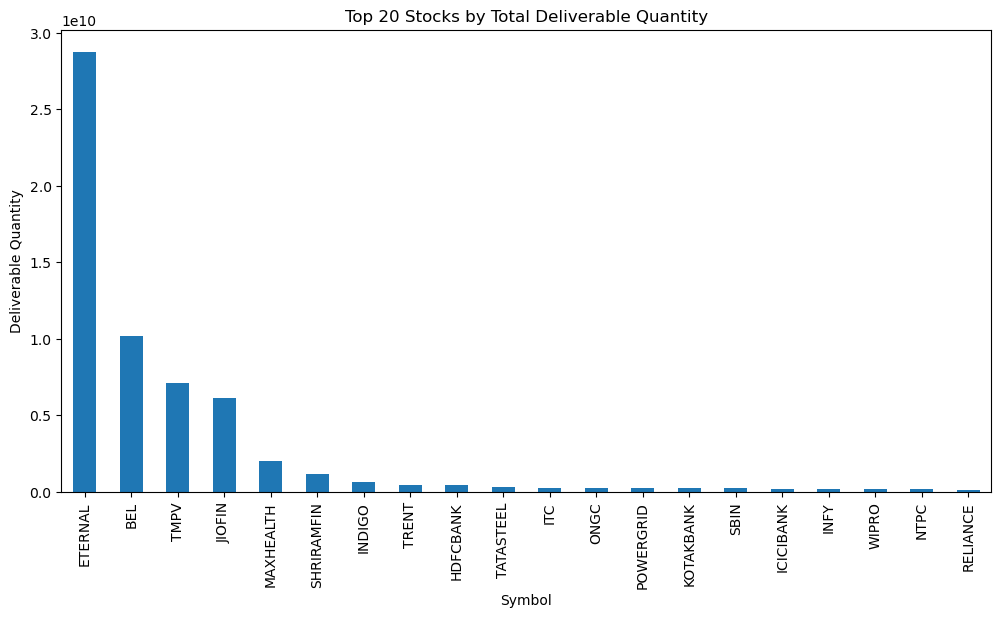

In [36]:
nse.groupby("Symbol")["DeliverableQty"].sum().sort_values(ascending=False).head(20).plot(kind="bar", figsize=(12, 6), title="Top 20 Stocks by Total Deliverable Quantity", ylabel="Deliverable Quantity")

# Which stocks are the most liquid?

 Liquidity Score combines turnover, traded quantity, and trading frequency into a single measure, helping identify stocks that can be bought or sold quickly with minimal impact on their market price.

<Axes: title={'center': 'Top 20 Most Liquid Stocks'}, xlabel='Symbol', ylabel='Liquidity Score'>

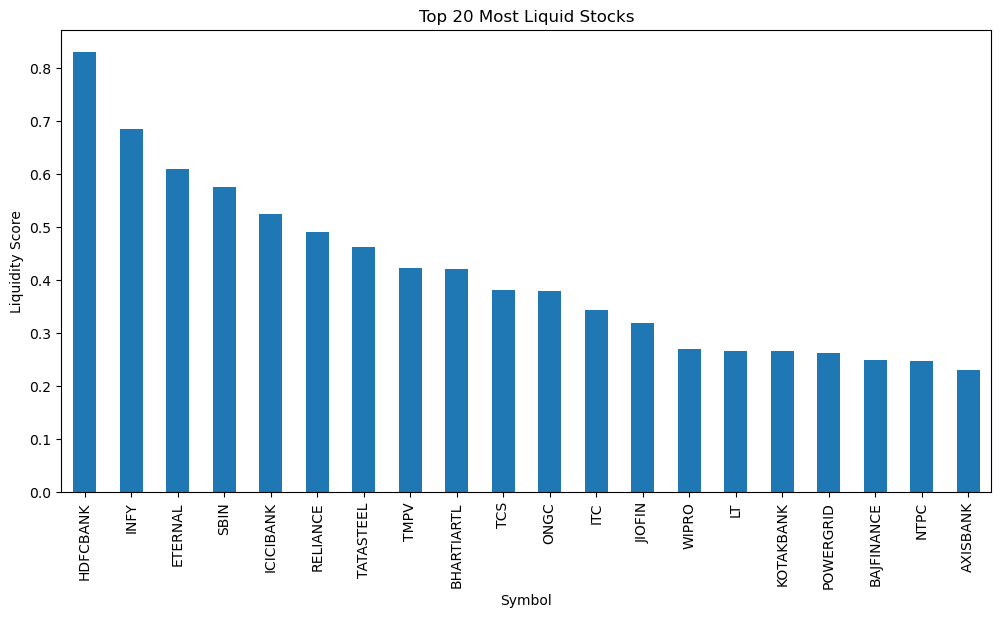

In [37]:
liquidity = nse.groupby("Symbol")[["TurnoverInRs", "TotalTradedQuantity", "No.ofTrades"]].mean()

liquidity = (liquidity - liquidity.min()) / (liquidity.max() - liquidity.min())

liquidity["LiquidityScore"] = liquidity.mean(axis=1)

liquidity["LiquidityScore"].sort_values(ascending=False).head(20).plot(kind="bar", figsize=(12, 6), title="Top 20 Most Liquid Stocks", ylabel="Liquidity Score")